In [32]:
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from incdbscan.incrementaldbscan import IncrementalDBSCAN

In [33]:
df_hist = pd.read_csv("data_history_min.csv")
df_stream = pd.read_csv("data_stream_min.csv")

label_col = "is_fraud"
time_col = "timestamp"

df_hist = df_hist.sort_values(by=time_col)
df_stream = df_stream.sort_values(by=time_col)

features = [
    "Velocity_Anomaly",
    "Value_Anomaly",
    "TimeGap_Anomaly",
    "Location_Anomaly",
    "Network_Anomaly",
]

X_hist = df_hist[features].values
X_stream = df_stream[features].values
y_hist = df_hist[label_col].values if label_col in df_hist.columns else None
y_stream = df_stream[label_col].values if label_col in df_stream.columns else None

scaler = StandardScaler()
X_hist = scaler.fit_transform(X_hist)
X_stream = scaler.transform(X_stream)

In [34]:
def evaluate_model(model, X, y_true=None):
    start = time.perf_counter()

    if hasattr(model, "fit_predict"):
        labels = model.fit_predict(X)
    else:
        raise AttributeError("Model không có fit_predict")

    elapsed = time.perf_counter() - start
    mem = psutil.Process().memory_info().rss / 1024**2

    if len(set(labels)) <= 1:
        sil, db, ari = np.nan, np.nan, np.nan
    else:
        sil = silhouette_score(X, labels)
        ari = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan

    return {
        "time": elapsed,
        "memory_MB": mem,
        "silhouette": sil,
        "ARI": ari,
        "labels": labels,
    }

In [35]:
models = {
    "KMeans": KMeans(n_clusters=5, random_state=42),
    "HAC": AgglomerativeClustering(n_clusters=5),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=5),
}

results_before = {name: evaluate_model(model, X_hist, y_hist) for name, model in models.items()}

# IncrementalDBSCAN xử lý riêng
idbscan = IncrementalDBSCAN(eps=0.7, min_pts=6)
start = time.perf_counter()
idbscan.insert(X_hist)
labels_hist = idbscan.get_cluster_labels(X_hist)
elapsed = time.perf_counter() - start
mem = psutil.Process().memory_info().rss / 1024**2

sil = silhouette_score(X_hist, labels_hist) if len(set(labels_hist)) > 1 else np.nan
ari = adjusted_rand_score(y_hist, labels_hist) if y_hist is not None else np.nan

results_before["IncrementalDBSCAN"] = {
    "time": elapsed,
    "memory_MB": mem,
    "silhouette": sil,
    "ARI": ari,
    "labels": labels_hist,
}

In [36]:
# 3 mô hình tĩnh: fit lại toàn bộ
X_all = np.vstack([X_hist, X_stream])
y_all = np.concatenate([y_hist, y_stream]) if y_hist is not None else None

results_after = {name: evaluate_model(model, X_all, y_all) for name, model in models.items()}

# IncrementalDBSCAN: chỉ insert thêm stream
start = time.perf_counter()
idbscan.insert(X_stream)
labels_all = idbscan.get_cluster_labels(X_all)
elapsed = time.perf_counter() - start
mem = psutil.Process().memory_info().rss / 1024**2

sil = silhouette_score(X_all, labels_all) if len(set(labels_all)) > 1 else np.nan
ari = adjusted_rand_score(y_all, labels_all) if y_all is not None else np.nan

results_after["IncrementalDBSCAN"] = {
    "time": elapsed,
    "memory_MB": mem,
    "silhouette": sil,
    "ARI": ari,
    "labels": labels_all,
}


In [37]:
stability = {}
for algo in results_before.keys():
    before = results_before[algo]["labels"]
    after = results_after[algo]["labels"][: len(before)]
    if len(set(before)) > 1 and len(set(after)) > 1:
        stability[algo] = adjusted_rand_score(before, after)
    else:
        stability[algo] = np.nan

In [39]:
summary_before = pd.DataFrame(
    {
        "Algorithm": list(results_before.keys()),
        "Time (s)": [results_before[a]["time"] for a in results_before],
        "Memory (MB)": [results_before[a]["memory_MB"] for a in results_before],
        "Silhouette": [results_before[a]["silhouette"] for a in results_before],
        "ARI": [results_before[a]["ARI"] for a in results_before],
    }
)

summary_after = pd.DataFrame(
    {
        "Algorithm": list(results_after.keys()),
        "Time (s)": [results_after[a]["time"] for a in results_after],
        "Memory (MB)": [results_after[a]["memory_MB"] for a in results_after],
        "Silhouette": [results_after[a]["silhouette"] for a in results_after],
        "ARI": [results_after[a]["ARI"] for a in results_after],
        "Stability": [stability[a] for a in results_after],
    }
)

print("\nKẾT QUẢ TRƯỚC KHI STREAMING:")
print(summary_before.round(4))
print("--------------------------------------------------------------------------------")
print("\nKẾT QUẢ MÔ PHỎNG STREAMING:")
print(summary_after.round(4))


KẾT QUẢ TRƯỚC KHI STREAMING:
           Algorithm  Time (s)  Memory (MB)  Silhouette     ARI
0             KMeans    0.0109     291.9766      0.1819  0.0574
1                HAC    3.0740     292.0664      0.1170  0.0623
2             DBSCAN    0.2831     292.6289     -0.2801  0.2091
3  IncrementalDBSCAN   46.9165     310.1289      0.4738  0.6124
--------------------------------------------------------------------------------

KẾT QUẢ MÔ PHỎNG STREAMING:
           Algorithm  Time (s)  Memory (MB)  Silhouette     ARI  Stability
0             KMeans    0.0163     309.6094      0.1790  0.0641     0.4727
1                HAC    5.3444     309.7109      0.1098  0.0666     0.1585
2             DBSCAN    0.3538     310.3047     -0.2643  0.2785     0.8750
3  IncrementalDBSCAN   27.5979     169.2695      0.4931  0.6925     0.9396


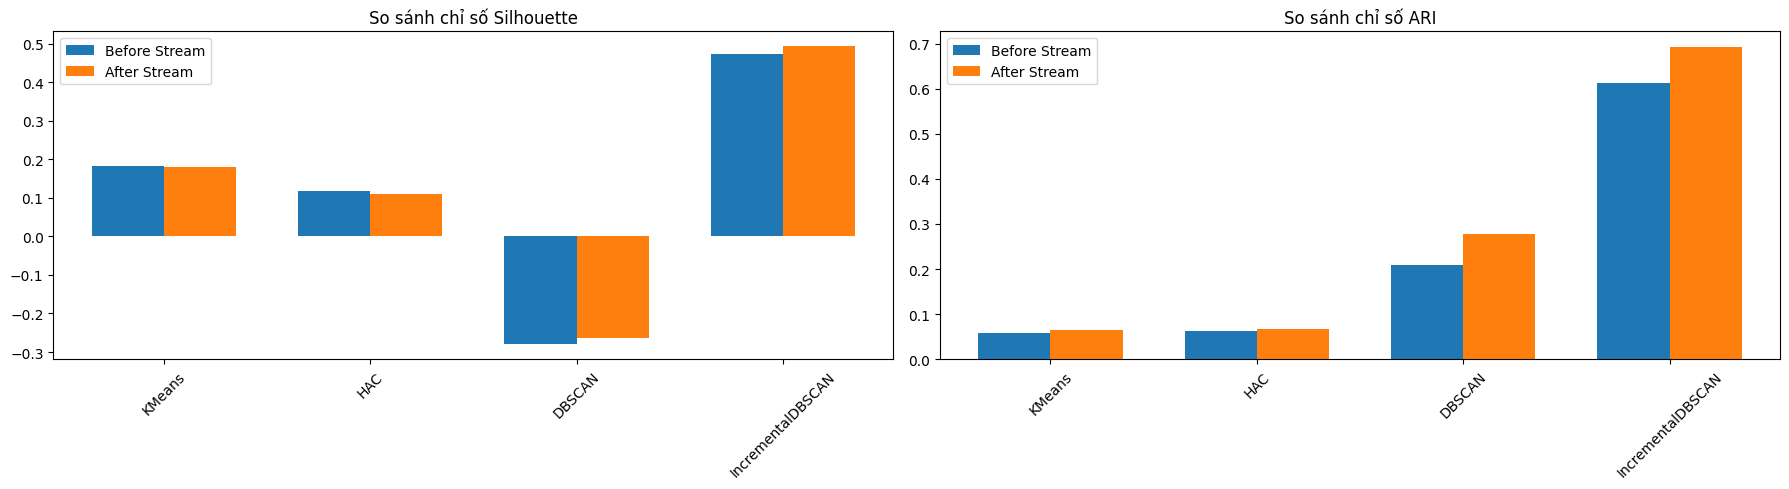

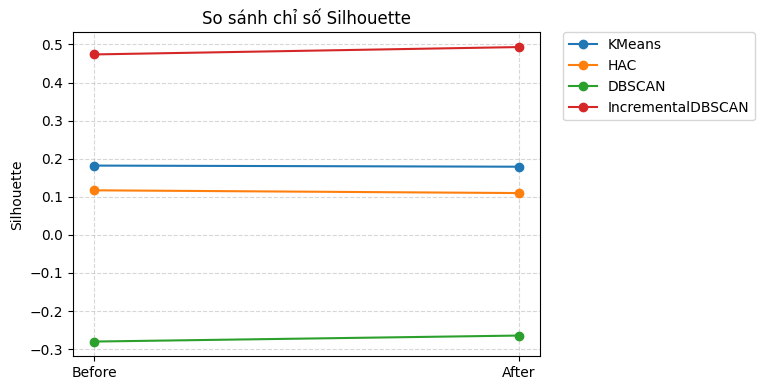

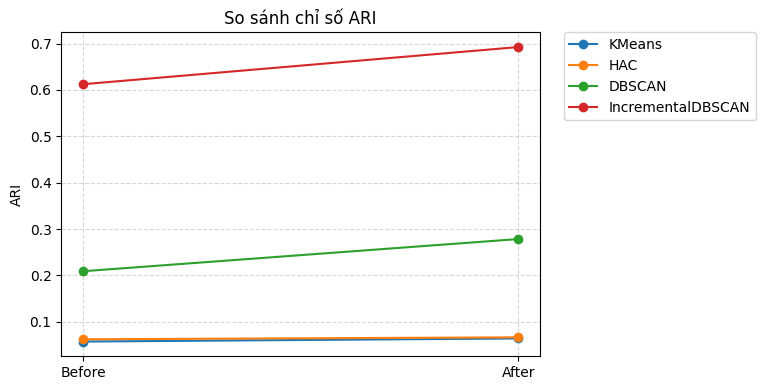

In [42]:
metrics = ["Silhouette", "ARI"]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
for ax, m in zip(axes, metrics):
    before_vals = summary_before.set_index("Algorithm")[m]
    after_vals = summary_after.set_index("Algorithm")[m]
    x = np.arange(len(before_vals))
    width = 0.35

    ax.bar(x - width / 2, before_vals, width, label="Before Stream")
    ax.bar(x + width / 2, after_vals, width, label="After Stream")
    ax.set_title(f"So sánh chỉ số {m}")
    ax.set_xticks(x)
    ax.set_xticklabels(before_vals.index, rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()

# slope graph
for m in metrics:
    df_plot = pd.DataFrame({
        "Algorithm": summary_before["Algorithm"],
        "Before": summary_before[m],
        "After": summary_after[m],
    })
    
    plt.figure(figsize=(7, 4))
    for _, row in df_plot.iterrows():
        plt.plot(["Before", "After"], [row["Before"], row["After"]],
                 marker="o", label=row["Algorithm"])
    
    plt.title(f"So sánh chỉ số {m}")
    plt.ylabel(m)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(rect=[0, 0, 0.8, 1])  # chừa chỗ bên phải cho legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()